# 5. Evaluation and Comparison

In [ ]:
# go to the repo root
os.chdir('/content/Deforestation_Detection')

# just to check:
print(os.getcwd())
print(os.listdir())

/content/Deforestation_Detection
['predictor.py', '.ipynb_checkpoints', '2_Local_Challenge.ipynb', '.gitignore', '5_Evaluation.ipynb', 'data', '4_Model_Application.ipynb', 'attention_unet', '1_Replication.ipynb', '3_Dataset_Curation.ipynb', 'models_paper', 'test', 'images', 'train', 'preprocessing_paper', 'environment.yml', 'metrics_paper', 'val', 'models_switzerland', '.gitmodules', 'preprocessing_switzerland', 'README.md', '.git']


## 5.1 Critical Reflection

**Performance Metrics**

This model achieves higher test IoU (0.9839) than the original Amazon
deforestation paper (0.9516). Also on the other metrics, the adapted model performs stronger. One-sample t-tests on the reported metrics of the model/paper show that our Swiss Alps model significantly outperforms the original Amazon model (p < 0.05) for all metrics.

If we look cricially at this, sever aspects could explain this stellar results, despite from the improved adaptation:

1. Task Simplification: Ice has a unique
   spectral signature (high NDSI values) with clear boundaries, whereas
   vegetation classes have overlapping spectral characteristics. This may make it easier for the model.

2. Data Advantages: This work uses 6 spectral bands (including SWIR) vs.
   the paper's 4, and exclusively summer imagery to eliminate snow confusion.
   The NDSI-based preprocessing further filters to glacier-relevant regions.

3. Evaluation Limitations: The test set comprises only 101 images from a
   single region (Jungfrau-Aletsch) and season (summer). This limited
   diversity may inflate performance metrics through overfitting to local
   characteristics.

However, we also adopted a more advanced model, with dropout layer, Learning rate scheduler and Dice loss function, among others. This has also a positive impact on the performance.


**The question of acceptable performance trade-offs extends beyond technical
metrics to encompass broader sustainability considerations:**

On the one hand, the Jungfrau–Aletsch region is both a UNESCO World Heritage site and a crucial water source for downstream settlements and hydropower.
Rapid glacier retreat affects summer low-flow river regimes, sediment loads and infrastructure, tourism (skiing, alpine huts, glacier access), and natural hazard risk (rockfall, GLOFs, slope destabilisation).

A system like this can help local authorities, cantonal agencies and hydropower operators maintain an up-to-date picture of glacier change without requiring expensive aerial campaigns every year.
With the available data, you could even push it further and make a model that predicts where the next biggest glacier retreat  will be.

On the other hand, deploying an AI model is costly, and we should take into account some considerations:

Environmental Trade-offs:
- The model's development required an estimated 12-24 GPU hours (inclusive hyperparameter tuning), which is only on a 'limited' amount of data
plus the carbon debt of pre-training the Amazon model. Operational
deployment would incur ongoing infrastructure costs. 
- Traditional ground-based
monitoring, while more limited in spatial coverage, has a smaller carbon
footprint and generates more transparant and trusthworthy ground-truth data.
- This trade-off should be taken into account when deciding wheter to monitor glacier retreat on a daily basis. A fair reflection could be taht the marginal benefit of pushing IoU from 0.97 to 0.98 must be weighed against additional compute and energy use, especially if simpler models would already be good enough for decision-making.

Ethical Considerations:
- Data is now processed
without consultation with Alpine communities whose livelihoods depend on
glacier-fed water systems. While the technical results are strong, the research
does not address:
    - Whether affected communities prioritize automated monitoring
    - How results would be communicated to and used by local stakeholders  
    - What traditional ecological knowledge could complement AI findings
    - Who controls access to glacier data and decision-making authority
These aspects should be carefully addressed before moving to a large-scale project. Local knowledge is needed e.g. for creating ground masks, and for interpretation for model results, as not all aspects can be addressed by a model.

Infrastructure Dependencies:
The model requires continued access to:
- Sentinel-2 satellites (European Space Agency)
- GPU compute clusters (institutional resources)
- ML expertise 
- Software frameworks maintained by tech corporations

These dependencies could create barriers to replication in low-resource settings and
concentrate power in institutions with existing technological infrastructure. However, in order for the model to be ethically deployed, it is important that also low-resource areas have access to the results and insights form the model, and that local communities are inccluded in the discussion.

A lower-performing but locally-owned, lower-carbon, community-controlled
monitoring system might better serve long-term sustainability goals despite
inferior technical metrics. The "best" model depends critically on the purpose:
accuracy for scientific publication, or actionable knowledge for affected
communities?

This project showed both what AI can do for sustainability work and where we need to be careful. Transfer learning worked surprisingly well: a model trained for deforestation could be repurposed for glacier segmentation with strong results. **But there are a few important points to keep in mind**:

- Power dynamics: The tools that make projects like this possible; satellite data, compute, technical expertise:; are mostly concentrated in the Global North. That creates an imbalance where those most affected by glacier retreat, such as Alpine communities living downstream, have little say in how these systems are designed or used.

- Environmental footprint: AI isn’t impact-free. Training, hardware production and maintenance all contribute to emissions. We should eventually compare the environmental cost of automated monitoring with traditional field-based methods to understand whether the trade-off is genuinely sustainable.

- When we rely heavily on satellite-derived quantitative data, there’s a risk of sidelining local knowledge and lived experience. A more just approach would combine AI insights with human expertise instead of treating automation as a replacement.

Overall, the point isn’t to step away from AI in sustainability, but to rethink how we use it. The future should move away from extractive, tech-first approaches and toward more collaborative, community-driven, and justice-oriented tools that genuinely support the people most impacted by climate change, not just those with the strongest computational resources.

To close this project, the main limitations of the implementation are listed below:

**Geographic and temporal scope**
- Training and evaluation are limited to a single region and only in the summer season.  
- Model behaviour on winter imagery, other Swiss glacier systems, or non-Alpine regions is unknown and would probably not perform well due to the misinterpretion to see recent snow as ice.

**Label quality and uncertainty**
- Ground-truth masks may contain boundary uncertainty or errors in debris-covered zones, but the model treats them as exact.  
- Using domain knowledge could improve this.

**Metric focus**
- Evaluation focuses on pixel-wise IoU, F1, Precision and Recall.  
- There is no assessment of object-level metrics (e.g. detecting full glacier units, small hanging glaciers) or of incorporating environmental cotsts into the metrics.

**Social and institutional integration**
- No direct engagement with agencies or communities who would realistically use such a system.  
- Therefore, no validation that chosen trade-offs (such as false positives vs false negatives) align with stakeholder needs.


Actionable policy and practice recommendations/next steps could be:

**Integrate AI segmentation into national glacier monitoring**
- Encourage agencies to test the model as a *decision-support tool* rather than a replacement for human-led inventories.  
- Use AI outputs to flag areas of rapid change where field surveys or drone flights should be prioritised.

**Co-design with local stakeholders**
- Involve valley communities, mountain guides, hydropower operators and hazard authorities in defining what counts as an “acceptable error”.  
- For example, stakeholders may prefer slightly more false positives over missing potentially unstable ice.

**Open, low-carbon infrastructure**
- Release trained models and code openly, and provide lightweight inference scripts that run on CPUs or modest GPUs.  
- Document energy use of training and inference, and explore model compression or knowledge distillation so NGOs and smaller agencies can adopt the method.

**Link to policy indicators**
- Align outputs with metrics already used in climate adaptation policies:  
  - annual glacier area/volume change  
  - pro-glacial lake formation  
  - retreat distance relative to infrastructure  
- This helps policymakers integrate AI-derived information into hazard zoning, water-allocation decisions and long-term adaptation planning.

## 5.2 Performance metrics in line with original paper

### Imports & functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pickle
import os
import glob

import tensorflow as tf

from tensorflow.keras.models import load_model
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
from scipy import stats


In [ ]:
def load_npy_list(directory):
    files = sorted(glob.glob(os.path.join(directory, "*.npy")))
    arrays = [np.load(f) for f in files]
    return arrays, files


#BASE_DIR = r"data_switzerland/preprocessed_data"
BASE_DIR = "/content/Deforestation_Detection"


train_img_dir2 = os.path.join(BASE_DIR, "train", "X")
train_msk_dir2 = os.path.join(BASE_DIR, "train", "Y")
val_img_dir2   = os.path.join(BASE_DIR, "val", "X")
val_msk_dir2   = os.path.join(BASE_DIR, "val", "Y")
test_img_dir2 = os.path.join(BASE_DIR, "test", "X")
test_msk_dir2 = os.path.join(BASE_DIR, "test", "Y")

training_images2, training_image_files2   = load_npy_list(train_img_dir2)
training_masks2,  training_mask_files2    = load_npy_list(train_msk_dir2)
validation_images2, validation_img_files2 = load_npy_list(val_img_dir2)
validation_masks2,  validation_msk_files2 = load_npy_list(val_msk_dir2)
test_images2, test_image_files2   = load_npy_list(test_img_dir2)
test_masks2,  test_mask_files2    = load_npy_list(test_msk_dir2)

print("len(validation_images2):", len(validation_images2))
print("len(validation_masks2):", len(validation_masks2))
print("len(test_images2):", len(test_images2))
print("len(test_masks2):", len(test_masks2))


len(validation_images2): 100
len(validation_masks2): 100
len(test_images2): 101
len(test_masks2): 101


In [ ]:
# =========================================================
# Existing helper functions
# =========================================================

def reconstruct_array(model, image, rounded=False):
    """Returns array of mask prediction (512x512) for a single image."""
    if len(image.shape) == 3:          # (512,512,6)
        image = np.expand_dims(image, axis=0)  # (1,512,512,6)

    reconstruction = model.predict(image, verbose=0)
    reconstruction = reconstruction.reshape(512, 512)

    if rounded:
        reconstruction = np.round(reconstruction)

    return reconstruction

def precision_eval(model, images, masks):
    """Per-image precision scores."""
    precision_list = []
    for i in range(len(images)):
        img = images[i]
        if len(img.shape) == 3:
            img = np.expand_dims(img, axis=0)

        reconstruction = model.predict(img, verbose=0)
        reconstruction = reconstruction.reshape(512, 512)
        reconstruction = np.round(reconstruction).flatten()

        mask_flat = masks[i].flatten()
        precision_list.append(
            precision_score(mask_flat, reconstruction,
                            average='weighted', zero_division=0)
        )
    return precision_list

def recall_eval(model, images, masks):
    """Per-image recall scores."""
    recall_list = []
    for i in range(len(images)):
        img = images[i]
        if len(img.shape) == 3:
            img = np.expand_dims(img, axis=0)

        reconstruction = model.predict(img, verbose=0)
        reconstruction = reconstruction.reshape(512, 512)
        reconstruction = np.round(reconstruction).flatten()

        mask_flat = masks[i].flatten()
        recall_list.append(
            recall_score(mask_flat, reconstruction,
                         average='weighted', zero_division=0)
        )
    return recall_list

def f1_eval(model, images, masks):
    """Per-image F1 scores."""
    f1_list = []
    for i in range(len(images)):
        img = images[i]
        if len(img.shape) == 3:
            img = np.expand_dims(img, axis=0)

        reconstruction = model.predict(img, verbose=0)
        reconstruction = reconstruction.reshape(512, 512)
        reconstruction = np.round(reconstruction).flatten()

        mask_flat = masks[i].flatten()
        f1_list.append(
            f1_score(mask_flat, reconstruction,
                     average='weighted', zero_division=0)
        )
    return f1_list

def iou_eval(model, images, masks):
    """Per-image IoU (Jaccard) scores."""
    iou_list = []
    for i in range(len(images)):
        pred = reconstruct_array(model, images[i], rounded=True)
        flat_pred = pred.flatten()
        flat_act = masks[i].flatten()
        iou_list.append(
            jaccard_score(flat_act, flat_pred,
                          average='weighted', zero_division=0)
        )
    return iou_list

def mean_ci(values, alpha=0.05):
    """Return mean and 95% CI for a list of values."""
    values = np.array(values)
    n = len(values)
    mean = values.mean()
    std = values.std(ddof=1)
    t_val = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_low = mean - t_val * std / np.sqrt(n)
    ci_high = mean + t_val * std / np.sqrt(n)
    return mean, (ci_low, ci_high), std

def ttest_vs_paper(values, paper_value):
    """One-sample t-test: is our mean different from the paper's reported value?"""
    values = np.array(values)
    t_stat, p_val = stats.ttest_1samp(values, paper_value)
    return t_stat, p_val


### Results

In [ ]:
history = np.load('models_switzerland/TESTMODEL_history.npy', allow_pickle='TRUE').item()
MODEL_PATH = "models_switzerland/TESTMODEL.keras"

custom_objects = {}
model = load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)

In [ ]:
paper_metrics = {
    "Test": {
        "IoU":       0.9516,
        "Precision": 0.9758,
        "Recall":    0.9748,
        "F1":        0.9753,
    },
    "Validation": {
        "IoU":       0.9581,
        "Precision": 0.9790,
        "Recall":    0.9779,
        "F1":        0.9785,
    }
}

# ---------------------------------------------------------
# Evaluate model on Validation and Test (per-image metrics)
# ---------------------------------------------------------

splits = {
    "Validation": (validation_images2, validation_masks2),
    "Test":       (test_images2,       test_masks2),
}

results_per_split = {}

for split_name, (imgs, msks) in splits.items():
    prec_list = precision_eval(model, imgs, msks)
    rec_list  = recall_eval(model, imgs, msks)
    f1_list   = f1_eval(model, imgs, msks)
    iou_list  = iou_eval(model, imgs, msks)

    metrics = {}
    for metric_name, values in [
        ("IoU",       iou_list),
        ("Precision", prec_list),
        ("Recall",    rec_list),
        ("F1",        f1_list),
    ]:
        mean, ci, std = mean_ci(values)
        metrics[metric_name] = {
            "values":  values,
            "mean":    mean,
            "ci_low":  ci[0],
            "ci_high": ci[1],
            "std":     std,
        }

    results_per_split[split_name] = metrics

In [50]:
metrics_list = ["IoU", "Precision", "Recall", "F1"]
splits_order = ["Validation", "Test"]

formatted_rows = []

for split_name in splits_order:
    if split_name not in results_per_split:
        continue

    for metric in metrics_list:
        if metric not in results_per_split[split_name]:
            continue

        stats = results_per_split[split_name][metric]
        mean    = stats["mean"]
        ci_low  = stats["ci_low"]
        ci_high = stats["ci_high"]

        # Format: mean [CI_low, CI_high]
        our_str = f"{mean:.4f} [{ci_low:.4f}, {ci_high:.4f}]"

        # Paper value
        paper_val = paper_metrics.get(split_name, {}).get(metric, None)
        paper_str = f"{paper_val:.4f}" if paper_val is not None else "-"

        formatted_rows.append({
            "Split": split_name,
            "Metric": metric,
            "Our result (95% CI)": our_str,
            "Paper result": paper_str
        })

compact_df = pd.DataFrame(formatted_rows)
display(compact_df)


,Split,Metric,Our result (95% CI),Paper result
0,Validation,IoU,"0.9892 [0.9865, 0.9919]",0.9581
1,Validation,Precision,"0.9945 [0.9931, 0.9959]",0.9790
2,Validation,Recall,"0.9944 [0.9930, 0.9958]",0.9779
3,Validation,F1,"0.9944 [0.9930, 0.9958]",0.9785
4,Test,IoU,"0.9910 [0.9885, 0.9936]",0.9516
5,Test,Precision,"0.9954 [0.9942, 0.9967]",0.9758
6,Test,Recall,"0.9954 [0.9941, 0.9967]",0.9748
7,Test,F1,"0.9954 [0.9941, 0.9967]",0.9753


,Split,Metric,Our_mean,Paper_value,t_stat,p_value,significant
0,Validation,IoU,0.9892,0.9581,22.73,0.0000,True
1,Validation,Precision,0.9945,0.9790,22.01,0.0000,True
2,Validation,Recall,0.9944,0.9779,23.35,0.0000,True
3,Validation,F1,0.9944,0.9785,22.53,0.0000,True
4,Test,IoU,0.9910,0.9516,30.82,0.0000,True
5,Test,Precision,0.9954,0.9758,30.20,0.0000,True
6,Test,Recall,0.9954,0.9748,31.05,0.0000,True
7,Test,F1,0.9954,0.9753,30.43,0.0000,True


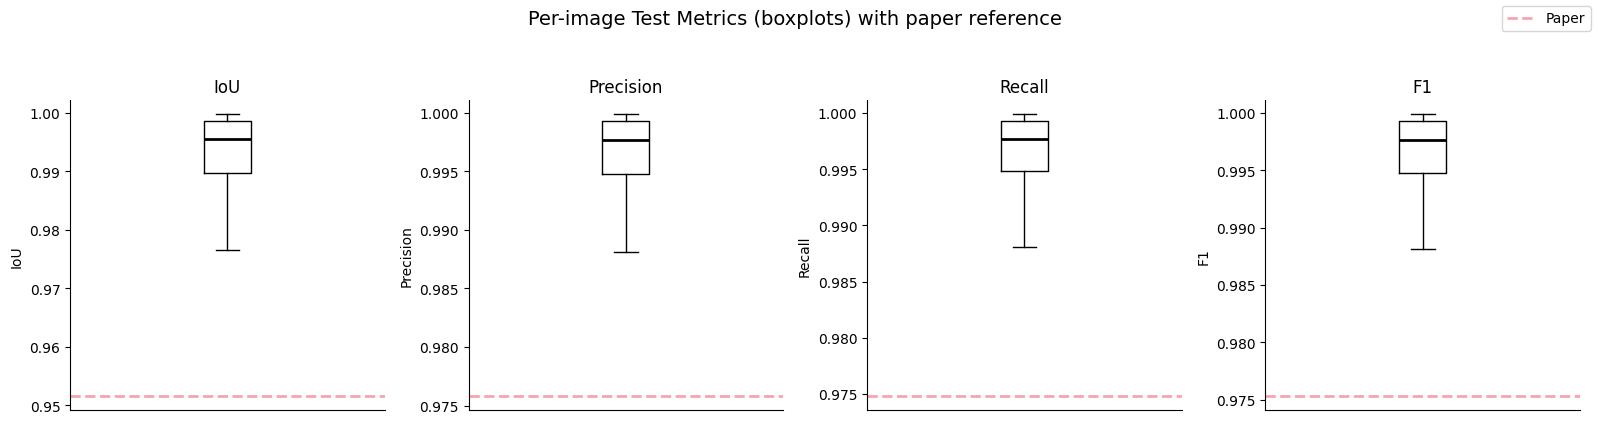

In [ ]:
# One-sample t-tests vs paper metrics for Validation + Test
ttest_rows = []

for split_name in ["Validation", "Test"]:
    if split_name not in paper_metrics:
        continue
    split_metrics = results_per_split[split_name]

    for m in ["IoU", "Precision", "Recall", "F1"]:
        if m not in paper_metrics[split_name]:
            continue

        values = split_metrics[m]["values"]
        paper_val = paper_metrics[split_name][m]
        t_stat, p_val = ttest_vs_paper(values, paper_val)

        ttest_rows.append({
            "Split": split_name,
            "Metric": m,
            "Our_mean": split_metrics[m]["mean"],
            "Paper_value": paper_val,
            "t_stat": t_stat,
            "p_value": p_val,
            "significant": p_val < 0.05
        })

ttest_df = pd.DataFrame(ttest_rows)

def highlight_sig(row):
    """Maak Our_mean en p_value rood/vet als p < 0.05."""
    styles = [''] * len(row)
    if row['significant']:
        for i, col in enumerate(row.index):
            if col in ["Our_mean", "p_value"]:
                styles[i] = 'color: red; font-weight: bold;'
    return styles

display(
    ttest_df.style
        .apply(highlight_sig, axis=1)
        .format({
            "Our_mean": "{:.4f}",
            "Paper_value": "{:.4f}",
            "t_stat": "{:.2f}",
            "p_value": "{:.4f}"
        })
)


# boxplots
test_metrics = results_per_split["Test"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

metric_order = ["IoU", "Precision", "Recall", "F1"]

for ax, m in zip(axes, metric_order):
    values = test_metrics[m]["values"]
    ax.boxplot(values, showfliers=False)
    ax.set_title(m)
    ax.set_xticks([])

    if "Test" in paper_metrics and m in paper_metrics["Test"]:
        ax.axhline(paper_metrics["Test"][m], color="red", linestyle="--", label="Paper")

    ax.set_ylabel(m)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right")

plt.suptitle("Per-image Test Metrics (boxplots) vs Paper value", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()



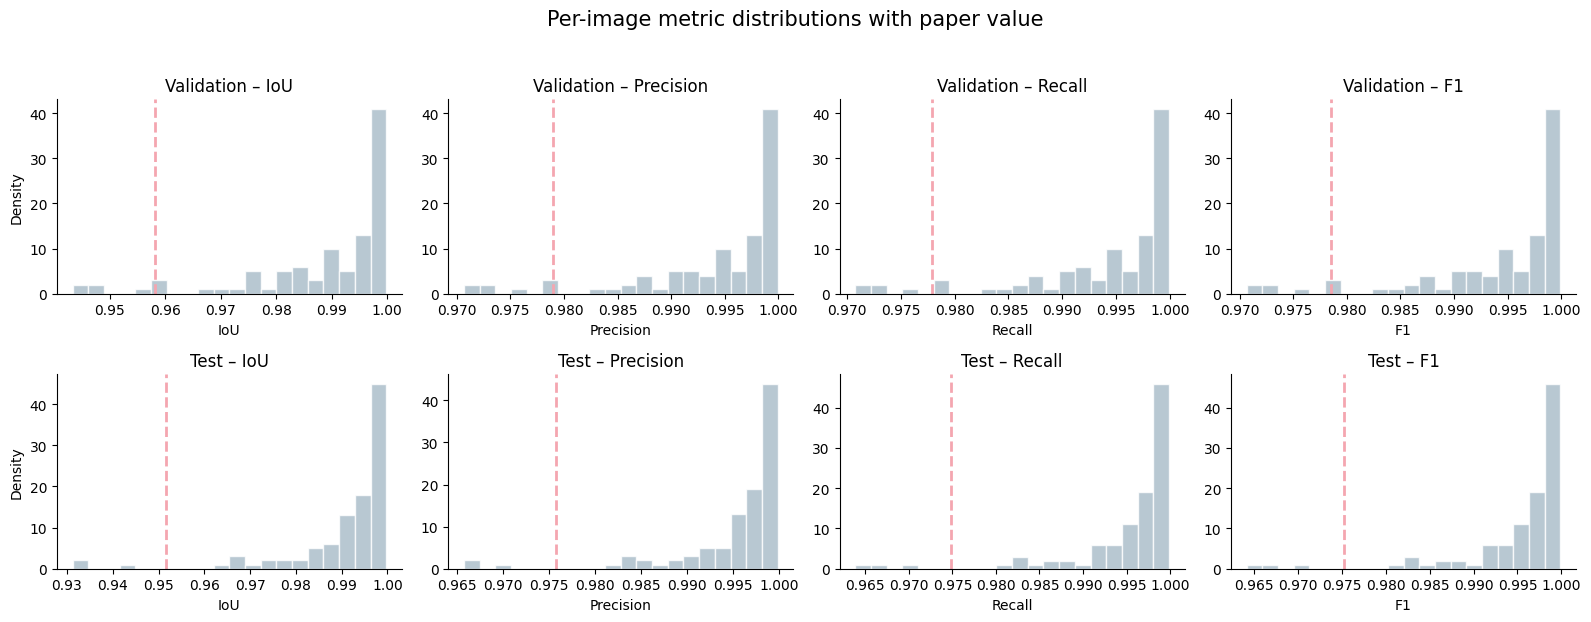

In [ ]:
grey_blue = "#A7BBC7"
pastel_pink = "#F4A6B0"

splits_plot = ["Validation", "Test"]
metrics_plot = ["IoU", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(len(splits_plot), len(metrics_plot), figsize=(16, 6), sharey=False)

for row, split_name in enumerate(splits_plot):
    if split_name not in results_per_split:
        for col in range(len(metrics_plot)):
            axes[row, col].axis("off")
        continue

    for col, metric in enumerate(metrics_plot):
        ax = axes[row, col]
        metric_stats = results_per_split[split_name].get(metric)

        if metric_stats is None:
            ax.axis("off")
            continue

        values = np.array(metric_stats["values"])
        values = values[~np.isnan(values)]

        if len(values) == 0:
            ax.axis("off")
            continue

        # --- Histogram ---
        ax.hist(
            values,
            bins=20,
            density=False,
            alpha=0.8,
            color=grey_blue,
            edgecolor="white"
        )
        # paper value
        if split_name in paper_metrics and metric in paper_metrics[split_name]:
            paper_val = paper_metrics[split_name][metric]
            ax.axvline(
                paper_val,
                linestyle="--",
                linewidth=2,
                color=pastel_pink,
                label="Paper"
            )

        ax.set_title(f"{split_name} – {metric}")
        ax.set_xlabel(metric)
        if col == 0:
            ax.set_ylabel("Density")

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.suptitle("Per-image metric distributions with paper value", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()


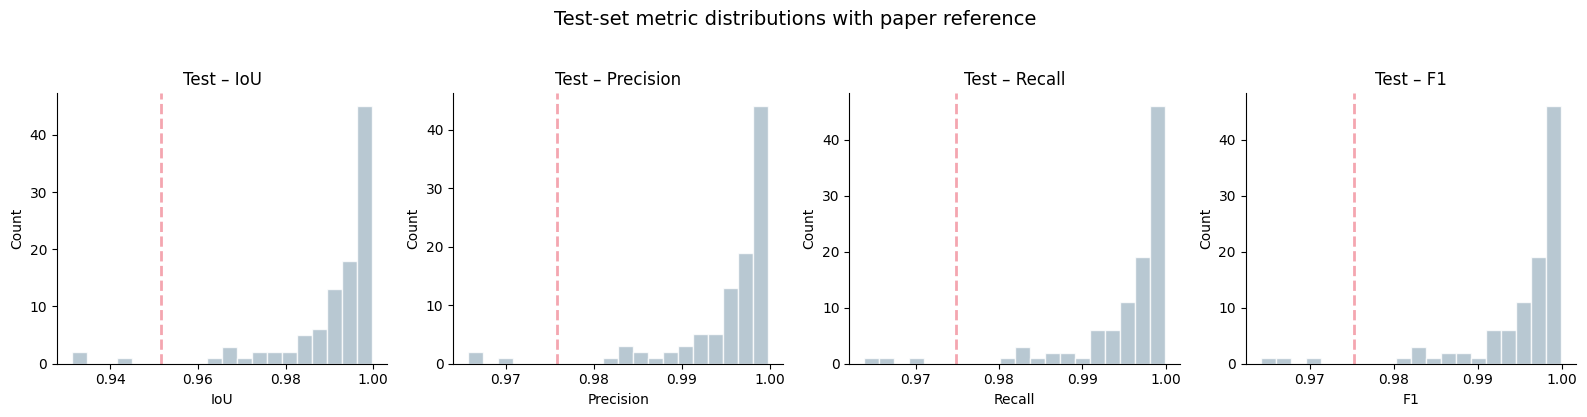

In [ ]:
# Colors (consistent with your training plots)
grey_blue = "#A7BBC7"    # histogram color
pastel_pink = "#F4A6B0"  # vertical paper line

metrics_plot = ["IoU", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

split_name = "Test"

for ax, metric in zip(axes, metrics_plot):
    # Check if metric exists
    if split_name not in results_per_split:
        ax.axis("off")
        continue

    metric_stats = results_per_split[split_name].get(metric)
    if metric_stats is None:
        ax.axis("off")
        continue

    # Extract per-image values and clean NaNs
    values = np.array(metric_stats["values"])
    values = values[~np.isnan(values)]

    if len(values) == 0:
        ax.axis("off")
        continue

    # --- Density Histogram ---
    ax.hist(
        values,
        bins=20,
        density=False,
        alpha=0.8,
        color=grey_blue,
        edgecolor="white"
    )

    # --- Vertical paper reference line ---
    if split_name in paper_metrics and metric in paper_metrics[split_name]:
        paper_val = paper_metrics[split_name][metric]
        ax.axvline(
            paper_val,
            linestyle="--",
            linewidth=2,
            color=pastel_pink,
        )

    # Titles and labels
    ax.set_title(f"{split_name} – {metric}")
    ax.set_xlabel(metric)
    ax.set_ylabel("Count")

    # Clean, minimalist academic style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Test-set metric distributions with paper reference", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()


## 5.3 Error Analysis

In [ ]:
def get_predictions_and_scores(model, images, masks, threshold=0.5):
    """
    Compute per-image predictions, IoU scores and flattened arrays
    for confusion matrix.

    Returns:
        y_true_all  : flattened ground truth pixels over all images
        y_pred_all  : flattened predicted pixels over all images
        iou_scores  : array of IoU per image
        preds_per_img : list of 2D prediction masks (0/1)
    """
    if isinstance(images, list):
        images = np.array(images)
    if isinstance(masks, list):
        masks = np.array(masks)

    n = len(images)
    y_true_all = []
    y_pred_all = []
    iou_scores = []
    preds_per_img = []

    for i in range(n):
        img = images[i]
        msk = masks[i]

        if img.ndim == 3:
            img_batch = np.expand_dims(img, axis=0)  # (1, H, W, C)
        else:
            img_batch = img

        pred = model.predict(img_batch, verbose=0)[0]  # (H, W, 1) or (H, W)
        pred = np.squeeze(pred)
        pred_bin = (pred >= threshold).astype(int)

        msk = np.squeeze(msk)
        msk_bin = (msk >= 0.5).astype(int)

        y_true_all.append(msk_bin.flatten())
        y_pred_all.append(pred_bin.flatten())
        iou_scores.append(
            jaccard_score(
                msk_bin.flatten(),
                pred_bin.flatten(),
                average='binary',
                zero_division=0
            )
        )
        preds_per_img.append(pred_bin)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    iou_scores = np.array(iou_scores)

    return y_true_all, y_pred_all, iou_scores, preds_per_img

# === PREDICTION + IoU extraction ===
y_true_all, y_pred_all, iou_scores, preds_per_img = get_predictions_and_scores(
    model,
    test_images2,
    test_masks2,
    threshold=0.5
)


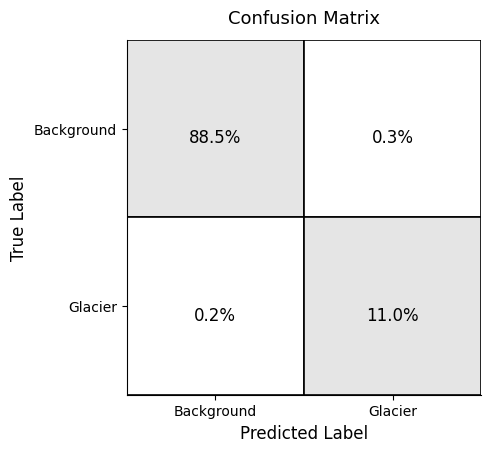

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_percent_only(y_true, y_pred):
    """
    Confusion matrix (percentages only):
    - Shows % of total pixels
    - TN & TP shaded grey
    - FP & FN white
    - No raw counts
    """
    cm = confusion_matrix(y_true, y_pred).astype(float)
    total = cm.sum()
    cm_percent = cm / total * 100

    # Shade correct predictions (diagonal)
    cell_colors = np.array([
        ["#E5E5E5", "#FFFFFF"],   # TN grey, FP white
        ["#FFFFFF", "#E5E5E5"]    # FN white, TP grey
    ])

    fig, ax = plt.subplots(figsize=(5, 5))

    # Draw colored tiles
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                facecolor=cell_colors[i, j],
                edgecolor="black",
                linewidth=1.2
            ))

    # Add ONLY percentages
    for i in range(2):
        for j in range(2):
            perc = cm_percent[i, j]
            ax.text(
                j + 0.5, i + 0.55,
                f"{perc:.1f}%",
                ha="center", va="center",
                fontsize=12,
                color="black"
            )

    # Axes formatting
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(["Background", "Glacier"], fontsize=10)
    ax.set_yticklabels(["Background", "Glacier"], fontsize=10)

    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title("Confusion Matrix", fontsize=13, pad=12)

    # Clean look
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

# Run
plot_confusion_matrix_percent_only(y_true_all, y_pred_all)


In [88]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def build_error_map(gt_mask, pred_mask):
    """
    Build an error map with 4 classes:
      0 = True Negative (background correctly predicted)
      1 = False Positive (predicted glacier, actually background)
      2 = False Negative (missed glacier)
      3 = True Positive (glacier correctly predicted)
    """
    gt = (gt_mask > 0.5).astype(int)
    pr = (pred_mask > 0.5).astype(int)

    error_map = np.zeros_like(gt, dtype=np.uint8)

    tn = (gt == 0) & (pr == 0)
    fp = (gt == 0) & (pr == 1)
    fn = (gt == 1) & (pr == 0)
    tp = (gt == 1) & (pr == 1)

    error_map[tn] = 0
    error_map[fp] = 1
    error_map[fn] = 2
    error_map[tp] = 3

    return error_map

# Softer but still visible colours
# Strong colours for errors
fp_color = "#FF5C8A"   # bright pink for false positives
fn_color = "#4A90E2"   # bright blue for false negatives

# Soft neutral tones for correct pixels
tn_color = "#DADADA"   # light grey
tp_color = "#A0E6A0"   # light green

error_cmap = ListedColormap([tn_color, fp_color, fn_color, tp_color])

fp_rates = []
fn_rates = []

for i in range(len(test_images2)):
    true_mask = test_masks2[i].flatten()
    pred_mask = preds_per_img[i].flatten()

    # Avoid division by zero
    fp = np.sum((pred_mask == 1) & (true_mask == 0))
    fn = np.sum((pred_mask == 0) & (true_mask == 1))

    total_pred_pos = np.sum(pred_mask == 1) + 1e-6
    total_true_pos = np.sum(true_mask == 1) + 1e-6

    fp_rates.append(fp / total_pred_pos)
    fn_rates.append(fn / total_true_pos)

fp_rates = np.array(fp_rates)
fn_rates = np.array(fn_rates)

def show_mask_error_example(image, gt_mask, pred_mask, idx=None):
    """
    Show:
      - RGB image
      - Ground truth mask
      - Predicted mask
      - Error map (TN/FP/FN/TP in different colours)
    """
    gt = np.squeeze(gt_mask)
    pr = np.squeeze(pred_mask)

    # Build error map
    err = build_error_map(gt, pr)

    # Simple RGB from first 3 bands
    if image.shape[-1] >= 3:
        rgb = image[..., :3]
        # normalise for display
        p2, p98 = np.percentile(rgb, (2, 98))
        rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)
    else:
        rgb = np.repeat(image[..., :1], 3, axis=-1)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # RGB
    axes[0].imshow(rgb)
    axes[0].set_title(f"Image #{idx}" if idx is not None else "Image")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(gt, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(pr, cmap="gray")
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    # Error map
    im = axes[3].imshow(err, cmap=error_cmap, vmin=0, vmax=3)
    axes[3].set_title(
    "Error Map\n Red: FP, Blue: FN",
    fontsize=11
)
    axes[3].axis("off")

    for ax in axes:
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


k = 40
top_fp_idx = np.argsort(fp_rates)[-k:]
top_fn_idx = np.argsort(fn_rates)[-k:]

print("=== FP-heavy examples ===")
for idx in top_fp_idx:
    show_mask_error_example(test_images2[idx], test_masks2[idx], preds_per_img[idx], idx=idx)

print("=== FN-heavy examples ===")
for idx in top_fn_idx:
    show_mask_error_example(test_images2[idx], test_masks2[idx], preds_per_img[idx], idx=idx)


Output hidden; open in https://colab.research.google.com to view.

### Qualitative Analysis

In [ ]:
def enhance_rgb_display(rgb_image, method='percentile'):
    """Simple contrast stretch for nicer RGB display."""
    if method == 'percentile':
        p2, p98 = np.percentile(rgb_image, (2, 98))
        if p98 - p2 > 0:
            enhanced = (rgb_image - p2) / (p98 - p2)
        else:
            enhanced = rgb_image
    else:
        enhanced = rgb_image
    return np.clip(enhanced, 0, 1)

# --- 1. Kies 20 random testbeelden en maak voorspellingen ---
np.random.seed(42)
n_samples = min(20, len(test_images2))
random_indices = np.random.choice(len(test_images2), size=n_samples, replace=False)

predictions_20 = []
iou_scores_20 = []

for idx in random_indices:
    img = test_images2[idx]
    if img.ndim == 3:
        img_batch = np.expand_dims(img, axis=0)

    pred = model.predict(img_batch, verbose=0)[0]
    pred = pred.reshape(512, 512)
    pred_bin = np.round(pred)

    predictions_20.append(pred_bin)

    flat_pred = pred_bin.flatten()
    flat_mask = test_masks2[idx].flatten()
    iou = jaccard_score(flat_mask, flat_pred, average='weighted', zero_division=0)
    iou_scores_20.append(iou)

# --- 2. Visualiseer: per rij RGB | GT | Prediction ---
fig = plt.figure(figsize=(12, 3 * n_samples))

for row, test_idx in enumerate(random_indices):
    # RGB (eerste 3 banden)
    ax1 = plt.subplot(n_samples, 3, row*3 + 1)
    rgb = test_images2[test_idx][..., :3]
    rgb_disp = enhance_rgb_display(rgb, method='percentile')
    ax1.imshow(rgb_disp)
    ax1.set_title(f'Sample {row+1}\nIoU: {iou_scores_20[row]:.3f}', fontsize=8)
    ax1.axis('off')

    # Ground truth
    ax2 = plt.subplot(n_samples, 3, row*3 + 2)
    ax2.imshow(test_masks2[test_idx], cmap='gray')
    ax2.set_title('Ground Truth', fontsize=8)
    ax2.axis('off')

    # Prediction
    ax3 = plt.subplot(n_samples, 3, row*3 + 3)
    ax3.imshow(predictions_20[row], cmap='gray')
    ax3.set_title('Prediction', fontsize=8)
    ax3.axis('off')

plt.suptitle(
    '20 Random Test Samples: RGB | Ground Truth | Prediction\n(White = Ice, Black = Non-Ice)',
    fontsize=12, fontweight='bold', y=0.998
)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('models_switzerland/20_samples_predictions.png', dpi=200, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ---------------------------------------------------
# 1. Generate predictions and per-image IoU on TEST
# ---------------------------------------------------
predictions = []
iou_scores = []

for i in range(len(test_images2)):
    pred = reconstruct_array(model, test_images2[i], rounded=True)
    predictions.append(pred)

    flat_pred = pred.flatten()
    flat_mask = test_masks2[i].flatten()
    iou = jaccard_score(flat_mask, flat_pred, average='weighted', zero_division=0)
    iou_scores.append(iou)

iou_scores = np.array(iou_scores)

# ---------------------------------------------------
# 2. Select 10 worst and 10 best samples
# ---------------------------------------------------
sorted_idx = np.argsort(iou_scores)
worst_10 = sorted_idx[:10]
best_10  = sorted_idx[-10:][::-1]   # highest first

# ---------------------------------------------------
# 3. Helper to plot a list of indices
# ---------------------------------------------------
def plot_samples(indices, title_prefix, title_color):
    n = len(indices)
    fig = plt.figure(figsize=(12, 3 * n))

    for row, i in enumerate(indices):
        # RGB
        ax1 = plt.subplot(n, 3, row*3 + 1)
        rgb = test_images2[i][..., :3]
        rgb_disp = enhance_rgb_display(rgb)
        ax1.imshow(rgb_disp)
        ax1.set_title(f'{title_prefix} #{row+1}\nIoU: {iou_scores[i]:.3f}',
                      fontsize=9, color=title_color)
        ax1.axis('off')

        # Ground Truth
        ax2 = plt.subplot(n, 3, row*3 + 2)
        ax2.imshow(test_masks2[i], cmap='gray')
        ax2.set_title('Ground Truth', fontsize=8)
        ax2.axis('off')

        # Prediction
        ax3 = plt.subplot(n, 3, row*3 + 3)
        ax3.imshow(predictions[i], cmap='gray')
        ax3.set_title('Prediction', fontsize=8)
        ax3.axis('off')

    plt.suptitle(
        f'{title_prefix} Predictions: RGB | Ground Truth | Prediction\n(White = Ice, Black = Non-Ice)',
        fontsize=12, fontweight='bold', y=0.998
    )
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

# ---------------------------------------------------
# 4. Plot 10 worst and 10 best
# ---------------------------------------------------
plot_samples(worst_10, title_prefix="Worst", title_color="red")
plot_samples(best_10,  title_prefix="Best",  title_color="green")


Output hidden; open in https://colab.research.google.com to view.

Some examples after data augmentation

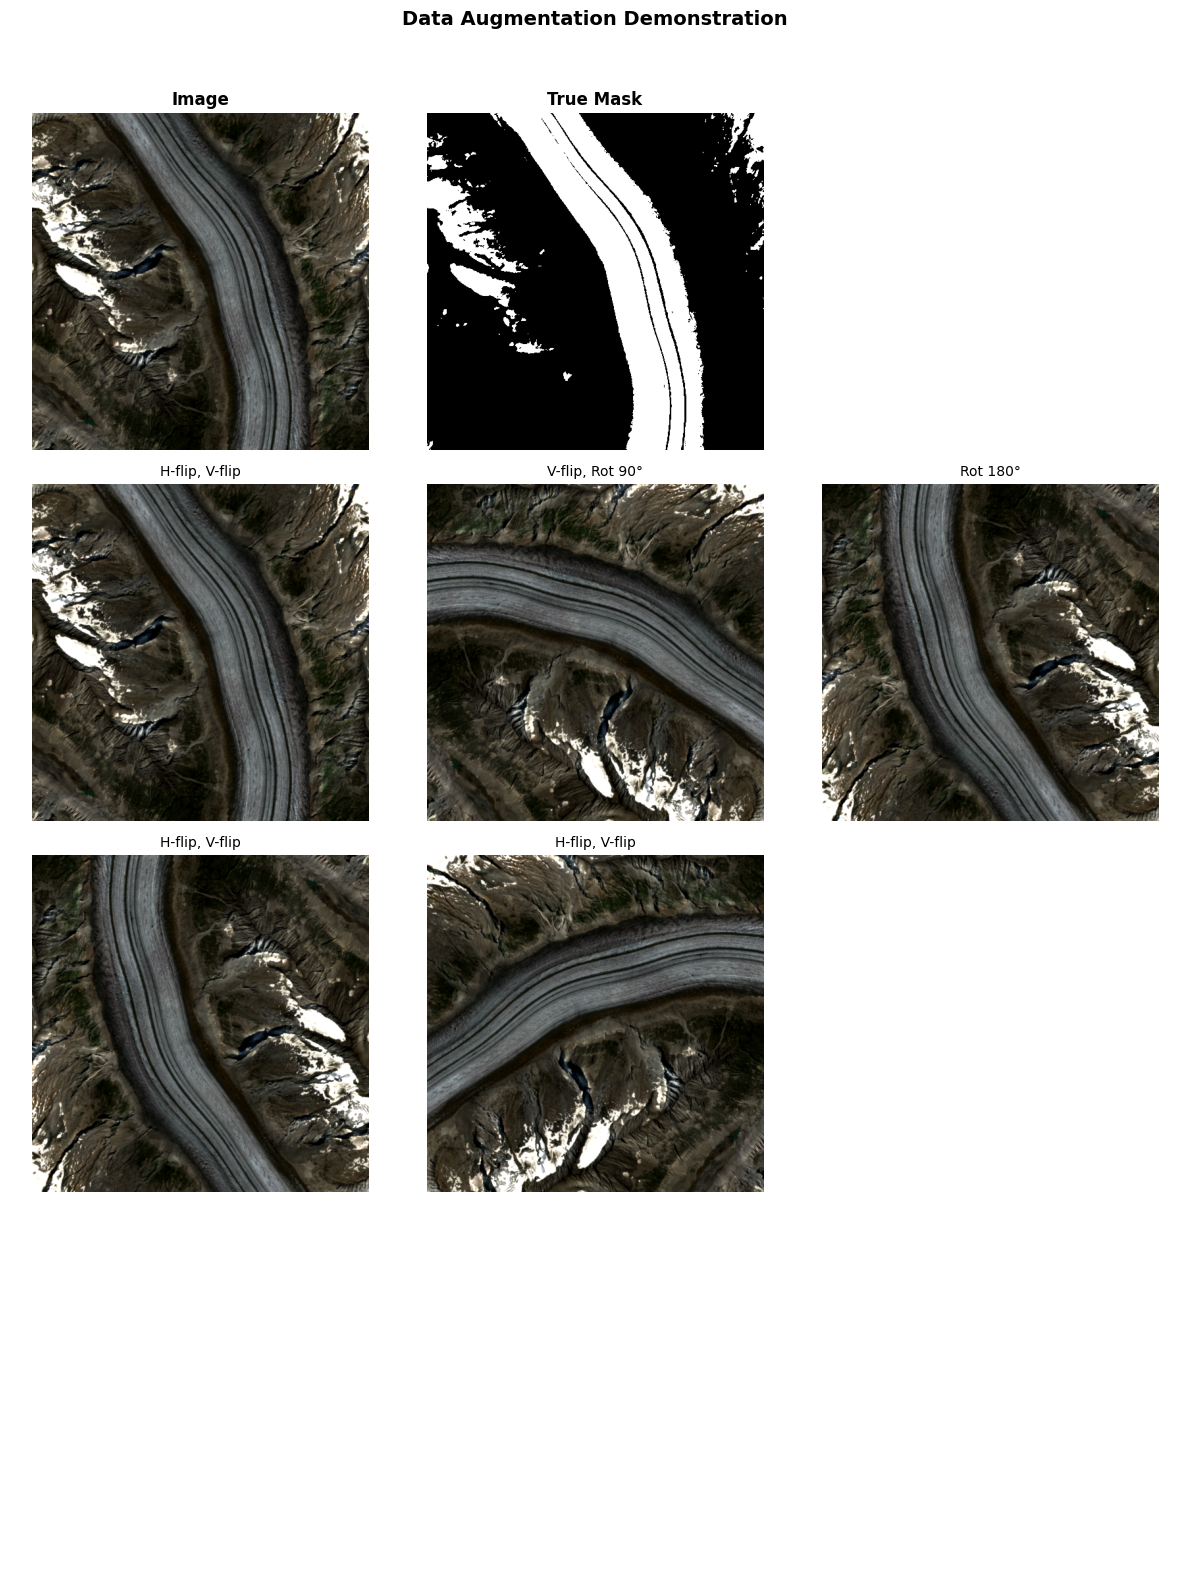

In [83]:
def demonstrate_augmentation_fixed(image, mask, n_augmentations=5):
    """
    Show how ONE image gets augmented differently.
    Grid: 4 rows × 3 columns = 12 subplots.
    Row 0: Original RGB + Original Mask.
    Rows 1–3: n_augmentations variants (RGB only).
    """
    fig, axes = plt.subplots(4, 3, figsize=(12, 16))
    axes = axes.ravel()

    # Zet alles eerst uit
    for ax in axes:
        ax.axis('off')

    # --- Original RGB ---
    axes[0].imshow(enhance_rgb_display(image[..., :3]))
    axes[0].set_title('Image', fontsize=12, fontweight='bold')

    # --- Original Mask ---
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('True Mask', fontsize=12, fontweight='bold')

    # --- Augmentaties ---
    for i in range(n_augmentations):
        aug_img = image.copy()
        aug_mask = mask.copy()
        desc = []

        # Random horizontal flip
        if np.random.rand() > 0.5:
            aug_img = np.fliplr(aug_img)
            aug_mask = np.fliplr(aug_mask)
            desc.append("H-flip")

        # Random vertical flip
        if np.random.rand() > 0.5:
            aug_img = np.flipud(aug_img)
            aug_mask = np.flipud(aug_mask)
            desc.append("V-flip")

        # Random rotation (0, 90, 180, 270)
        k = np.random.randint(0, 4)
        if k:
            aug_img = np.rot90(aug_img, k)
            aug_mask = np.rot90(aug_mask, k)
            desc.append(f"Rot {k*90}°")

        # Random brightness
        if np.random.rand() > 0.5:
            factor = np.random.uniform(0.8, 1.2)
            aug_img = np.clip(aug_img * factor, 0, 1)
            desc.append(f"Bright×{factor:.1f}")

        if not desc:
            desc = ["No change"]

        # Plaats augmentatie in volgende beschikbare subplot (start vanaf index 3)
        ax = axes[3 + i]
        ax.imshow(enhance_rgb_display(aug_img[..., :3]))
        ax.set_title(", ".join(desc[:2]), fontsize=10)
        ax.axis('off')

    plt.suptitle(
        'Data Augmentation Demonstration',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


if 'training_images2' in globals() and 'training_masks2' in globals() and len(training_images2) > 0:
    demo_idx = np.random.randint(len(training_images2))
    demonstrate_augmentation_fixed(training_images2[demo_idx], training_masks2[demo_idx])


# Graphs for Poster Presentation

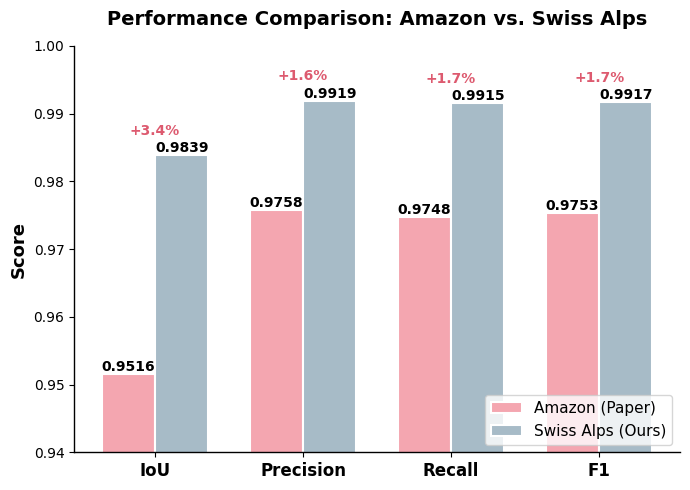

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics
metrics = ['IoU', 'Precision', 'Recall', 'F1']

paper_vals = [0.9516, 0.9758, 0.9748, 0.9753]  # Amazon (paper)
ours_vals  = [0.9839, 0.9919, 0.9915, 0.9917]  # Swiss Alps (ours)

# Color theme (your pastel palette)
pink_paper = "#F4A6B0"   # pastel pink for baseline
blue_ours  = "#A7BBC7"   # pastel grey-blue for your model

x = np.arange(len(metrics))
width = 0.36

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Bars
bars1 = ax.bar(
    x - width/2, paper_vals, width,
    label='Amazon (Paper)',
    color=pink_paper, edgecolor='white', linewidth=1.5
)

bars2 = ax.bar(
    x + width/2, ours_vals, width,
    label='Swiss Alps (Ours)',
    color=blue_ours, edgecolor='white', linewidth=1.5
)

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10, weight='bold'
        )

# Improvement percentages
improvements = [(o - p) / p * 100 for p, o in zip(paper_vals, ours_vals)]
for i, imp in enumerate(improvements):
    ax.text(
        x[i], max(paper_vals[i], ours_vals[i]) + 0.003,
        f'+{imp:.1f}%',
        ha='center', fontsize=10,
        color='#DD5A6F', weight='bold'   # a deeper pink for contrast
    )

# Labels and formatting
ax.set_ylabel('Score', fontsize=13, weight='bold')
ax.set_title('Performance Comparison: Amazon vs. Swiss Alps',
             fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, weight='bold')
ax.legend(fontsize=11, loc='lower right')

# Clean, minimalist style
ax.set_ylim(0.94, 1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# No gridlines
ax.grid(False)

plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
